# Jorge Carbajal SID: 862552655

# Data Challenge

## Organization

- **Shared setup**: imports, seeds, and paths (create `data` folder for the data and download from: https://data.transportation.gov/stories/s/Form-57-Data-Downloads/i5dw-jvsi/).
- **Data loading and cleaning**: Data transforming helper functions and the implementation of that transformation. I also included a short summary of the class balance.
- **Classification**: compare Decision Tree and TabNet on `injury_present`.
- **Clustering**: compare K-medoids/PAM and HDBSCAN on a shared sampled distance matrix.
- **Results**: show compact tables and plots for the final report.

## Shared Setup

### Imports

In [5]:
from pathlib import Path
import os
import random
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kmedoids
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

from IPython.display import display
from sklearn.cluster import HDBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

### Reproducibility

In [6]:
# decouple reproducability
SEED = 13
CLUSTER_SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

### Paths

In [16]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

RAW_DATA_PATTERN = "Highway-Rail_Grade_Crossing_Incident_Data_(Form_57)_*.csv"

matches = list(DATA_DIR.glob(RAW_DATA_PATTERN))

if not matches:
    raise FileNotFoundError(f"Expected raw data matching {DATA_DIR / RAW_DATA_PATTERN}")

RAW_DATA_PATH = max(matches, key=lambda p: p.stat().st_mtime)

## Data Loading and Cleaning

### Helper Functions

In [8]:
KEPT_FEATURES = [
    "Crossing Illuminated",
    "Crossing Users Injured",
    "Crossing Users Killed",
    "Crossing Warning Expanded 1",
    "Crossing Warning Expanded 2",
    "Crossing Warning Expanded 3",
    "Crossing Warning Expanded 4",
    "Crossing Warning Expanded 5",
    "Crossing Warning Expanded 6",
    "Crossing Warning Expanded 7",
    "Crossing Warning Expanded 8",
    "Crossing Warning Expanded 9",
    "Crossing Warning Expanded 10",
    "Crossing Warning Expanded 11",
    "Crossing Warning Expanded 12",
    "Date",
    "Driver In Vehicle",
    "Driver Passed Vehicle",
    "Employees Injured",
    "Employees Killed",
    "Equipment Involved",
    "Equipment Struck",
    "Equipment Type",
    "Estimated Vehicle Speed",
    "Highway User",
    "Highway User Action",
    "Highway User Position",
    "Hour",
    "Month",
    "Number of Cars",
    "Number Vehicle Occupants",
    "Passengers Injured",
    "Passengers Killed",
    "Report Key",
    "Temperature",
    "Time",
    "Total Injured Form 55A",
    "Total Injured Form 57",
    "Total Killed Form 55A",
    "Total Killed Form 57",
    "Track Type",
    "Train Speed",
    "Vehicle Damage Cost",
    "View Obstruction",
    "Visibility",
    "Warning Connected To Signal",
    "Weather Condition",
]

def transform_warning_devices(df) -> pd.DataFrame:
    """
    Transform the warning device columns into binary categories. Remove the columns and return the DataFrame.
    """

    df = df.copy()
    warning_columns = [f"Crossing Warning Expanded {i}" for i in range(1, 13)]
    normalized = df[warning_columns].apply(lambda col: col.astype("string").str.strip().str.lower())

    device_mapping = {
        "has_gate": ["gates", "gate"],
        "has_cantilever_fls": ["cantilever fls"],
        "has_standard_fls": ["standard fls"],
        "has_wig_wags": ["wig wags", "wig wag"],
        "has_highway_traffic_signals": ["highway traffic signals", "hwy. traffic signals"],
        "has_audible": ["audible"],
        "has_crossbucks": ["crossbucks", "crossbuck"],
        "has_stop_signs": ["stop signs", "stop sign"],
        "has_watchman": ["watchman"],
        "has_flagged_by_crew": ["flagged by crew"],
        "has_other_warning": ["other"],
        "has_no_warning_device": ["none"],
    }

    for new_column, possible_values in device_mapping.items():
        df[new_column] = normalized.isin(possible_values).any(axis=1).astype(int)

    return df.drop(columns=warning_columns)

def transform_time_variables(df) -> pd.DataFrame:
    """
    Create year, season, and time_of_day columns. Remove the Month, Hour, and Time columns.
    """

    df = df.copy()
    parsed_date = pd.to_datetime(df["Date"], errors="coerce")
    df["year"] = parsed_date.dt.year.astype("Int64")

    season_mapping = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Fall", 10: "Fall", 11: "Fall",
    }
    df["season"] = parsed_date.dt.month.map(season_mapping)

    parsed_time = pd.to_datetime(df["Time"], format="%I:%M %p", errors="coerce")
    hour = parsed_time.dt.hour
    df["time_of_day"] = pd.cut(
        hour,
        bins=[-1, 5, 11, 17, 23],
        labels=["Night", "Morning", "Afternoon", "Evening"],
    )

    return df.drop(columns=["Month", "Hour", "Time"])

def clean_numeric_features(df) -> pd.DataFrame:
    """
    Clean up Vehicle Damage numbering, and for all numerical features convert out of range values into NaN
    """

    df = df.copy()
    damage_cleaned = (
        df["Vehicle Damage Cost"].astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df["Vehicle Damage Cost"] = pd.to_numeric(damage_cleaned, errors="coerce")

    numeric_features = [
        "Train Speed",
        "Estimated Vehicle Speed",
        "Number Vehicle Occupants",
        "Number of Cars",
        "Temperature",
    ]
    for feature in numeric_features:
        df[feature] = pd.to_numeric(df[feature], errors="coerce")

    df.loc[df["Train Speed"] > 110, "Train Speed"] = pd.NA
    df.loc[df["Estimated Vehicle Speed"] > 120, "Estimated Vehicle Speed"] = pd.NA
    df.loc[df["Number of Cars"] > 300, "Number of Cars"] = pd.NA
    df.loc[(df["Temperature"] < -80) | (df["Temperature"] > 130), "Temperature"] = pd.NA

    return df

def build_v1_dataset(raw_df) -> pd.DataFrame:
    """
    Ensure we have all the KEPT_FEATURES, Drop duplicates, create outcome columns, apply all the above functions
    """

    missing_features = [feature for feature in KEPT_FEATURES if feature not in raw_df.columns]
    if missing_features:
        raise ValueError(f"Missing expected raw columns: {missing_features}")

    df = raw_df[KEPT_FEATURES].copy()
    df = df.drop_duplicates(subset="Report Key", keep="first").copy()

    killed_55a = pd.to_numeric(df["Total Killed Form 55A"], errors="coerce")
    injured_55a = pd.to_numeric(df["Total Injured Form 55A"], errors="coerce")
    df["fatality_present"] = (killed_55a > 0).astype(int)
    df["injury_present"] = (injured_55a > 0).astype(int)

    df = transform_warning_devices(df)
    df = transform_time_variables(df)
    df = clean_numeric_features(df)

    return df

### Implementation

In [9]:
raw_df = pd.read_csv(RAW_DATA_PATH, low_memory=False)
v1_df = build_v1_dataset(raw_df)

# injury_present is the target label for the supervised classification of the notebook. This help understand class balance before training and evaluation.
target_summary = (
    v1_df["injury_present"]
    .value_counts()
    .sort_index()
    .rename_axis("injury_present")
    .reset_index(name="count")
)
target_summary["percent"] = (target_summary["count"] / len(v1_df) * 100).round(2)
display(target_summary)

,injury_present,count,percent
0,0,182189,72.64
1,1,68617,27.36


## Classification

### Helper Functions

In [10]:
TARGET = "injury_present"
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

EXCLUDED_COLUMNS = [
    "injury_present",
    "Report Key",
    "Date",
    "year",
    "Crossing Users Injured",
    "Crossing Users Killed",
    "Employees Injured",
    "Employees Killed",
    "Passengers Injured",
    "Passengers Killed",
    "Total Injured Form 55A",
    "Total Injured Form 57",
    "Total Killed Form 55A",
    "Total Killed Form 57",
    "fatality_present",
    "Vehicle Damage Cost",
]

def get_excluded_columns(df) -> list:
    """
    Builds and returns a list of excluded columns and columns that are constant (constant columns provide no value).
    """

    excluded = [column for column in EXCLUDED_COLUMNS if column in df.columns]
    excluded_set = set(excluded)
    constant_columns = [
        column for column in df.columns
        if column != TARGET
        and column not in excluded_set
        and df[column].nunique(dropna=True) <= 1
    ]
    return excluded + constant_columns

def get_predictor_columns(df) -> list:
    """
    Return a list of the final columns we will use to model. Ensure no data leakage.
    """

    excluded = set(get_excluded_columns(df))
    predictors = [column for column in df.columns if column not in excluded]

    risky_words = ["injur", "kill", "fatal", "damage", "cost", "report", "key", "date"]
    risky_predictors = [
        column for column in predictors
        if any(word in column.lower() for word in risky_words)
    ]
    if risky_predictors:
        raise ValueError(f"Possible leakage predictors found: {risky_predictors}")

    return predictors

def get_feature_groups(df, predictors) -> dict:
    """
    Sort and return the predictor columns into three groups so they can later be further cleaned.
    """

    groups = {"numeric": [], "categorical": [], "binary": []}
    for column in predictors:
        values = set(df[column].dropna().unique().tolist())
        if values and values.issubset({0, 1}):
            groups["binary"].append(column)
        elif pd.api.types.is_numeric_dtype(df[column]):
            groups["numeric"].append(column)
        else:
            groups["categorical"].append(column)
    return groups

def make_splits(X, y):
    """
    Splits the data into and 80/20 model/test split. That 80 model split is then further split into another 80/20 train/val split. The validation split is meant for adjusting thresholds to produce better performance.
    """

    X_model, X_test, y_model, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_model,
        y_model,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        stratify=y_model,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def find_best_f1_threshold(y_true, probabilities) -> pd.Series:
    """
    This function finds returns the values produced by the threshold that produces the best F1 score.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    precision = precision[:-1]
    recall = recall[:-1]
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    results = pd.DataFrame({
        "threshold": thresholds,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    })
    results["predicted_positive_count"] = [int((probabilities >= t).sum()) for t in thresholds]
    return results.sort_values(["f1", "precision", "threshold"], ascending=[False, False, False]).iloc[0]

def metric_row(model_name, y_true, probabilities, threshold) -> dict:
    """
    Turns predictions into a clean summary of row evaluation metrics.
    """

    predictions = (probabilities >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": round(float(threshold), 4),
        "AP / PR-AUC": round(average_precision_score(y_true, probabilities), 4),
        "F1": round(f1_score(y_true, predictions, zero_division=0), 4),
        "precision": round(precision_score(y_true, predictions, zero_division=0), 4),
        "recall": round(recall_score(y_true, predictions, zero_division=0), 4),
        "predicted injury cases": int(predictions.sum()),
        "actual injury cases": int((y_true == 1).sum()),
        "rows": len(y_true),
    }

def build_tree_model(feature_groups) -> Pipeline:
    """
    Here we build the pipelines for the necessary data transformations. With numerical data we replace missing values with the median of the column. For categorical data we first replace missing values with the most frequent and then convert those columns into binary columns where each category is its own binary column. The binary pipeline replaced missing valuse with most frequent as well. Columns transformer is needed for applying select transformations to select columns.
    """

    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    binary_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, feature_groups["numeric"]),
        ("categorical", categorical_pipeline, feature_groups["categorical"]),
        ("binary", binary_pipeline, feature_groups["binary"]),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("tree", DecisionTreeClassifier(max_depth=8, min_samples_leaf=100, random_state=SEED)),
        # ("tree", DecisionTreeClassifier(random_state=SEED)),
    ])

### Splits & Feature groups

In [11]:
predictors = get_predictor_columns(v1_df)

feature_groups = get_feature_groups(v1_df, predictors)

X = v1_df[predictors].copy()
y = v1_df[TARGET].copy()

X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X, y)

### Decision Tree

In [12]:
tree_model = build_tree_model(feature_groups)
tree_model.fit(X_train, y_train)

tree_val_prob = tree_model.predict_proba(X_val)[:, 1]
tree_test_prob = tree_model.predict_proba(X_test)[:, 1]
tree_threshold = float(find_best_f1_threshold(y_val, tree_val_prob)["threshold"])

### TabNet Helper Functions

In [13]:
def prepare_tabnet_data(X_train, X_val, X_test, feature_groups):
    """
    Prepares the train/validate/test data for the TabNet model. The function ultimately returns the processed versions of those splits along with which columns are categorical and the amount of categories per those columns.
    """

    # TabNet requires a fixture feature order. Since tabnet recieves data as arrays, column position needs ordering.
    ordered_features = feature_groups["numeric"] + feature_groups["categorical"] + feature_groups["binary"]
    X_train_p = pd.DataFrame(index=X_train.index)
    X_val_p = pd.DataFrame(index=X_val.index)
    X_test_p = pd.DataFrame(index=X_test.index)

    # For each numeric column, calculate the median from the test set, and fill missing values with median inside train, validation, and test sets.
    for column in feature_groups["numeric"]:
        median_value = pd.to_numeric(X_train[column], errors="coerce").median()
        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            target[column] = pd.to_numeric(source[column], errors="coerce").fillna(median_value).astype("float32")

    # Convert text categories into integer codes from the training data. 
    cat_idxs = []
    cat_dims = []
    for column in feature_groups["categorical"]:
        train_values = X_train[column].astype("string").fillna("__MISSING__")
        categories = sorted(train_values.unique().tolist())
        mapping = {category: index for index, category in enumerate(categories)}
        unknown_code = len(categories)
        cat_idxs.append(ordered_features.index(column))
        cat_dims.append(unknown_code + 1)

        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            values = source[column].astype("string").fillna("__MISSING__")
            target[column] = values.map(mapping).fillna(unknown_code).astype("int64")

    # Fro each binary feature, find the most common from training data, fill train/val/test splits with that value
    for column in feature_groups["binary"]:
        mode_value = int(pd.to_numeric(X_train[column], errors="coerce").dropna().mode().iloc[0])
        for source, target in [(X_train, X_train_p), (X_val, X_val_p), (X_test, X_test_p)]:
            target[column] = pd.to_numeric(source[column], errors="coerce").fillna(mode_value).astype("int64")

    # Return the processed data in the required ordering
    return (
        X_train_p[ordered_features],
        X_val_p[ordered_features],
        X_test_p[ordered_features],
        cat_idxs,
        cat_dims,
    )

### TabNet

In [14]:
set_seed(SEED)

# prepare the data in a way suitable for tabnet
X_train_tab, X_val_tab, X_test_tab, cat_idxs, cat_dims = prepare_tabnet_data(
    X_train,
    X_val,
    X_test,
    feature_groups,
)

# tabnet model with default parameter. The category indexes and the dimensions per those categories are only non defaults
tabnet = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    seed=SEED,
    verbose=0,
)

tabnet.fit(
    X_train=X_train_tab.to_numpy(dtype=np.float32),
    y_train=y_train.to_numpy(dtype=np.int64),
    eval_set=[(X_val_tab.to_numpy(dtype=np.float32), y_val.to_numpy(dtype=np.int64))],
    eval_metric=["auc"],
    max_epochs=30,
    pin_memory=False,
)

tabnet_val_prob = tabnet.predict_proba(X_val_tab.to_numpy(dtype=np.float32))[:, 1]
tabnet_test_prob = tabnet.predict_proba(X_test_tab.to_numpy(dtype=np.float32))[:, 1]
# use the validation set to find the best threshold
tabnet_threshold = float(find_best_f1_threshold(y_val, tabnet_val_prob)["threshold"])

Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_auc = 0.73793


c:\dev\ML_data_challenge\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


### Classification Plot

,model,threshold,AP / PR-AUC,F1,precision,recall,predicted injury cases,actual injury cases,rows
0,Decision Tree,0.2674,0.4640,0.5291,0.3969,0.7934,27432,13724,50162
1,TabNet,0.2950,0.4874,0.5371,0.4155,0.7593,25081,13724,50162


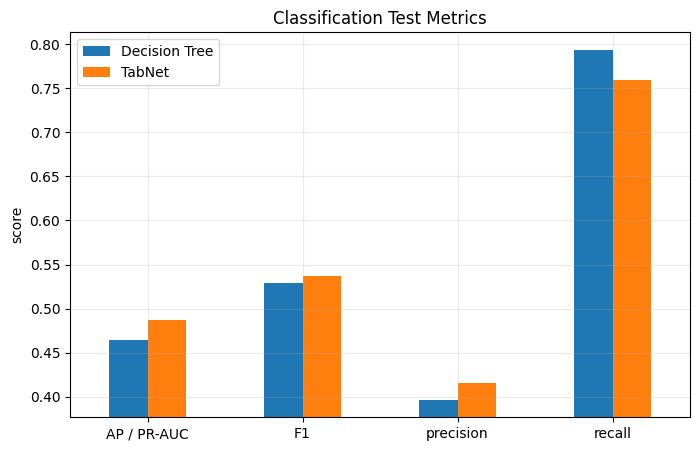

In [15]:
tree_results = metric_row("Decision Tree", y_test, tree_test_prob, tree_threshold)
tabnet_results = metric_row("TabNet", y_test, tabnet_test_prob, tabnet_threshold)
classification_results = pd.DataFrame([tree_results, tabnet_results])

display(classification_results)

metric_columns = ["AP / PR-AUC", "F1", "precision", "recall"]

fig, ax = plt.subplots(figsize=(8, 5))

classification_results.set_index("model")[metric_columns].T.plot(
    kind="bar",
    rot=0,
    ax=ax
)

# flatten metrics into an array
metric_values = classification_results[metric_columns].to_numpy().ravel()

padding = 0.02

y_min = max(0, metric_values.min() - padding)
y_max = min(1, metric_values.max() + padding)

ax.set_ylim(y_min, y_max)
ax.set_ylabel("score")
ax.set_title("Classification Test Metrics")
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

## Clustering

### Helper Functions

In [17]:
NUMERIC_CLUSTER_FEATURES = [
    "Train Speed",
    "Estimated Vehicle Speed",
    "Number Vehicle Occupants",
    "Number of Cars",
    "Temperature",
]

ALL_CATEGORICAL_CLUSTER_FEATURES = [
    "season",
    "time_of_day",
    "Highway User",
    "Highway User Position",
    "Equipment Involved",
    "Equipment Struck",
    "Equipment Type",
    "Track Type",
    "Warning Connected To Signal",
    "Crossing Illuminated",
    "Visibility",
    "Weather Condition",
    "View Obstruction",
    "Highway User Action",
    "Driver Passed Vehicle",
    "Driver In Vehicle",
]

CATEGORICAL_CLUSTER_FEATURES = [
    feature for feature in ALL_CATEGORICAL_CLUSTER_FEATURES
    if feature != "time_of_day"
]

BINARY_CLUSTER_FEATURES = [
    "has_gate",
    "has_cantilever_fls",
    "has_standard_fls",
    "has_wig_wags",
    "has_highway_traffic_signals",
    "has_audible",
    "has_crossbucks",
    "has_stop_signs",
    "has_watchman",
    "has_flagged_by_crew",
    "has_other_warning",
    "has_no_warning_device",
]

CLUSTER_FEATURES = NUMERIC_CLUSTER_FEATURES + CATEGORICAL_CLUSTER_FEATURES + BINARY_CLUSTER_FEATURES

def prepare_cluster_data(df):
    model_df = df[CLUSTER_FEATURES].copy()
    profile_df = df[["Report Key", "year", "fatality_present", "injury_present", "time_of_day"]].copy()

    for column in NUMERIC_CLUSTER_FEATURES:
        model_df[column] = pd.to_numeric(model_df[column], errors="coerce")
        model_df[column] = model_df[column].fillna(model_df[column].median())

    for column in CATEGORICAL_CLUSTER_FEATURES:
        model_df[column] = model_df[column].fillna("Missing").astype(str)

    for column in BINARY_CLUSTER_FEATURES:
        model_df[column] = pd.to_numeric(model_df[column], errors="coerce").astype(int)

    profile_df["time_of_day"] = profile_df["time_of_day"].astype("string").fillna("Missing").astype(str)
    return model_df, profile_df

def compute_gower_style_distance(model_sample, numeric_reference_df):
    n_rows = len(model_sample)
    distance_sum = np.zeros((n_rows, n_rows), dtype=np.float32)
    weight_sum = np.zeros((n_rows, n_rows), dtype=np.float32)

    for column in NUMERIC_CLUSTER_FEATURES:
        values = model_sample[column].to_numpy(dtype=np.float32)
        feature_range = numeric_reference_df[column].max() - numeric_reference_df[column].min()
        if feature_range == 0:
            continue
        distance_sum += np.abs(values[:, None] - values[None, :]) / feature_range
        weight_sum += 1

    for column in CATEGORICAL_CLUSTER_FEATURES:
        values = model_sample[column].astype(str).to_numpy()
        distance_sum += (values[:, None] != values[None, :]).astype(np.float32)
        weight_sum += 1

    for column in BINARY_CLUSTER_FEATURES:
        values = model_sample[column].to_numpy(dtype=np.int8)
        relevant = (values[:, None] == 1) | (values[None, :] == 1)
        different = values[:, None] != values[None, :]
        distance_sum += (different & relevant).astype(np.float32)
        weight_sum += relevant.astype(np.float32)

    distance_matrix = np.divide(distance_sum, weight_sum, out=np.zeros_like(distance_sum), where=weight_sum != 0)
    np.fill_diagonal(distance_matrix, 0.0)
    return distance_matrix

def run_pam(distance_matrix, k):
    result = kmedoids.pam(diss=distance_matrix, medoids=k, init="build", random_state=CLUSTER_SEED)
    return result.labels, result.medoids, float(result.loss)

def summarize_clusters(model_sample, profile_sample, labels):
    clustered = model_sample.copy()
    clustered["cluster"] = labels
    profiled = profile_sample.copy()
    profiled["cluster"] = labels

    sizes = pd.Series(labels).value_counts().sort_index()
    numeric = clustered.groupby("cluster")[NUMERIC_CLUSTER_FEATURES].median()
    outcomes = profiled.groupby("cluster")[["fatality_present", "injury_present"]].mean().mul(100)
    return sizes, numeric, outcomes

### Shared Sample and Distance Matrix

In [18]:
cluster_model_df, cluster_profile_df = prepare_cluster_data(v1_df)

sample_indices = cluster_model_df.sample(n=2000, random_state=CLUSTER_SEED).index
model_sample = cluster_model_df.loc[sample_indices].reset_index(drop=True)
profile_sample = cluster_profile_df.loc[sample_indices].reset_index(drop=True)

distance_matrix = compute_gower_style_distance(model_sample, cluster_model_df)

print(f"Sample rows: {len(model_sample):,}")
print(f"Distance matrix shape: {distance_matrix.shape}")
print(f"Distance matrix memory: {distance_matrix.nbytes / 1024**2:.2f} MB")
print(f"Minimum distance: {distance_matrix[np.triu_indices(len(distance_matrix), k=1)].min():.4f}")
print(f"Median distance: {np.median(distance_matrix[np.triu_indices(len(distance_matrix), k=1)]):.4f}")
print(f"Maximum distance: {distance_matrix.max():.4f}")

Sample rows: 2,000
Distance matrix shape: (2000, 2000)
Distance matrix memory: 15.26 MB
Minimum distance: 0.0039
Median distance: 0.4164
Maximum distance: 0.8465


### K-medoids / PAM

In [ ]:
pam_rows = []
pam_results = {}

for k in range(2, 9):
    labels, medoids, total_cost = run_pam(distance_matrix, k)
    silhouette = silhouette_score(distance_matrix, labels, metric="precomputed")
    sizes = pd.Series(labels).value_counts()
    pam_rows.append({
        "k": k,
        "silhouette": silhouette,
        "total_cost": total_cost,
        "smallest_cluster": int(sizes.min()),
        "largest_cluster": int(sizes.max()),
    })
    pam_results[k] = labels

pam_evaluation = pd.DataFrame(pam_rows)
selected_k = int(pam_evaluation.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
pam_labels = pam_results[selected_k]

display(pam_evaluation.round(4))
print(f"Selected k: {selected_k}")

pam_sizes, pam_numeric, pam_outcomes = summarize_clusters(model_sample, profile_sample, pam_labels)
display(pam_sizes.rename("rows").to_frame())
display(pam_numeric)
display(pam_outcomes)

### HDBSCAN

In [ ]:
hdbscan_rows = []
hdbscan_labels_by_params = {}

for method in ["eom", "leaf"]:
    for min_cluster_size in [5, 10, 15, 20, 25, 30, 50]:
        for min_samples in [None, 1, 3, 5, 10, 20]:
            model = HDBSCAN(
                metric="precomputed",
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_method=method,
                n_jobs=-1,
                copy=True,
            )
            labels = model.fit_predict(distance_matrix)
            clustered_mask = labels != -1
            clustered_labels = labels[clustered_mask]
            sizes = pd.Series(clustered_labels).value_counts()
            cluster_count = len(sizes)
            noise_percent = (labels == -1).mean() * 100
            clustered_count = int(clustered_mask.sum())
            silhouette = np.nan

            if cluster_count >= 2 and clustered_count > cluster_count:
                silhouette = silhouette_score(
                    distance_matrix[np.ix_(clustered_mask, clustered_mask)],
                    clustered_labels,
                    metric="precomputed",
                )

            hdbscan_rows.append({
                "method": method,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "cluster_count": cluster_count,
                "noise_percent": noise_percent,
                "clustered_count": clustered_count,
                "smallest_cluster": 0 if sizes.empty else int(sizes.min()),
                "largest_cluster": 0 if sizes.empty else int(sizes.max()),
                "clustered_silhouette": silhouette,
            })
            hdbscan_labels_by_params[(method, min_cluster_size, min_samples)] = labels

hdbscan_evaluation = pd.DataFrame(hdbscan_rows)
valid_hdbscan = hdbscan_evaluation[
    (hdbscan_evaluation["cluster_count"] >= 2)
    & (hdbscan_evaluation["noise_percent"] <= 90)
    & (hdbscan_evaluation["smallest_cluster"] >= 20)
    & hdbscan_evaluation["clustered_silhouette"].notna()
]

selected_hdbscan = valid_hdbscan.sort_values(
    ["clustered_silhouette", "noise_percent", "cluster_count"],
    ascending=[False, True, False],
).iloc[0]

hdbscan_key = (
    selected_hdbscan["method"],
    int(selected_hdbscan["min_cluster_size"]),
    None if pd.isna(selected_hdbscan["min_samples"]) else int(selected_hdbscan["min_samples"]),
)
hdbscan_labels = hdbscan_labels_by_params[hdbscan_key]

display(hdbscan_evaluation.sort_values("clustered_silhouette", ascending=False).head(12).round(4))
display(selected_hdbscan.to_frame("selected").T)

hdbscan_group_sizes = pd.Series(hdbscan_labels).replace(-1, "noise").value_counts()
display(hdbscan_group_sizes.rename("rows").to_frame())

### Clustering Results

In [ ]:
clustering_comparison = pd.DataFrame([
    {
        "method": "K-medoids / PAM",
        "sample rows": len(model_sample),
        "clusters": selected_k,
        "noise percent": 0.0,
        "clustered rows": len(model_sample),
        "main score": float(pam_evaluation.loc[pam_evaluation["k"] == selected_k, "silhouette"].iloc[0]),
        "score note": "silhouette on all points",
    },
    {
        "method": "HDBSCAN",
        "sample rows": len(model_sample),
        "clusters": int(selected_hdbscan["cluster_count"]),
        "noise percent": float(selected_hdbscan["noise_percent"]),
        "clustered rows": int(selected_hdbscan["clustered_count"]),
        "main score": float(selected_hdbscan["clustered_silhouette"]),
        "score note": "silhouette on non-noise points",
    },
])

display(clustering_comparison.round(4))

### Clustering Plot

In [ ]:
size_rows = []
for label, rows in pd.Series(pam_labels).value_counts().sort_index().items():
    size_rows.append({"method": "K-medoids", "group": f"cluster_{label}", "rows": int(rows)})

for label, rows in pd.Series(hdbscan_labels).replace(-1, "noise").value_counts().items():
    size_rows.append({"method": "HDBSCAN", "group": str(label), "rows": int(rows)})

cluster_size_df = pd.DataFrame(size_rows)
display(cluster_size_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, method in zip(axes, ["K-medoids", "HDBSCAN"]):
    subset = cluster_size_df[cluster_size_df["method"] == method]
    ax.bar(subset["group"], subset["rows"])
    ax.set_title(method)
    ax.set_xlabel("group")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("rows")
fig.suptitle("Clustering Group Sizes")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "clustering_group_sizes.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

In [ ]:
print("Classification")
print("- Decision Tree is the classical baseline.")
print("- TabNet is the recent tabular comparison method.")
print("- The test metrics show whether TabNet improves over the tree under the same split and threshold rule.")

print("\nClustering")
print("- K-medoids forces every sampled incident into one of the selected clusters.")
print("- HDBSCAN can label incidents as noise, so it tests whether dense profiles exist.")
print("- Outcome rates by cluster should be interpreted only as post-hoc descriptions.")